# Hackalysis : Open Source Repository Analysis


*Author: Eisha Tir Raazia*

In [52]:
import glob
import json
from dotenv import load_dotenv
import os
import pandas as pd
from pathlib import Path

load_dotenv()



def gather_repository_information(DATA_ROOT):
    data_dir = DATA_ROOT
# 1) Get all sub-directories inside data/
    repo_dirs = [d for d in glob.glob(str(data_dir / "*/"))]

# 2) Collect all *_github_repo_metadata.json files from those directories
    json_files = []
    for repo_dir in repo_dirs:
        json_files.extend(glob.glob(str(Path(repo_dir) / "**/*_github_repo_metadata.json"), recursive=True))

    #print(f"Found {len(repo_dirs)} directories")

# 3) Load and merge JSON content into rows
    frames = []

    for file_path in json_files:
        with open(file_path, "r", encoding="utf-8") as f:
            payload = json.load(f)

    # Expected shape: {repo_url: {field: value, ...}, ...}
        if isinstance(payload, dict) and all(isinstance(v, dict) for v in payload.values()):
            chunk_df = pd.DataFrame.from_dict(payload, orient="index")
            chunk_df.index.name = "repo_url"
            frames.append(chunk_df)
        else:
            print(f"Skipping unexpected JSON shape in: {file_path}")

# 4) Build one merged dataframe (index = repo_url, columns = metadata fields)
    repo_metadata_df = (
    pd.concat(frames, axis=0, sort=False)
    .loc[lambda d: ~d.index.duplicated(keep="last")]
    .sort_index()
    )
    
    return repo_dirs,json_files,repo_metadata_df


def get_project_data_paths(DATA_ROOT, provider_prefix: str = "lauzhack"):
    project_dirs = [
        folder for folder in sorted(DATA_ROOT.glob(f"{provider_prefix}-*"))
        if folder.is_dir()
    ]

    parquet_files = []
    for folder in project_dirs:
        projects_path = folder / f"{provider_prefix}_projects.parquet"
        github_projects_path = folder / f"{provider_prefix}_github_project_metadata.parquet"

        if github_projects_path.exists():
            parquet_files.append(github_projects_path)
        elif projects_path.exists():
            parquet_files.append(projects_path)

    return project_dirs, parquet_files


def _normalize_social_links(v):
    if v is None:
        return None
    if isinstance(v, str):
        return v.strip() or None
    if isinstance(v, list):
        cleaned = [str(x).strip() for x in v if str(x).strip()]
        return cleaned if cleaned else None
    if isinstance(v, dict):
        cleaned = {str(k): str(val).strip() for k, val in v.items() if str(val).strip()}
        return cleaned if cleaned else None
    return str(v).strip() or None


def _load_hackathon_metadata_row(metadata_json_path: Path, year: int) -> dict:
    metadata = json.loads(metadata_json_path.read_text(encoding="utf-8"))
    if isinstance(metadata, list):
        metadata = metadata[0] if metadata else {}
    if not isinstance(metadata, dict):
        metadata = {}

    row = {}
    for k, v in metadata.items():
        key = k if str(k).startswith("hackathon_") else f"hackathon_{k}"
        if str(k).lower().strip() in {
            "social", "socials", "social_link", "social_links",
            "hackathon_social_link", "hackathon_social_links"
        }:
            row["hackathon_social_links"] = _normalize_social_links(v)
        else:
            row[key] = v

    row["hackathon_year"] = year
    return row


def load_projects_analysis_ready(data_root: Path, provider_prefix: str = "lauzhack") -> pd.DataFrame:
    frames = []

    for folder in sorted(data_root.glob(f"{provider_prefix}-*")):
        if not folder.is_dir():
            continue

        year_str = folder.name.split("-")[-1]
        if not year_str.isdigit():
            continue
        year = int(year_str)

        projects_path = folder / f"{provider_prefix}_projects.parquet"
        github_projects_path = folder / f"{provider_prefix}_github_project_metadata.parquet"
        metadata_json_path = folder / f"{provider_prefix}_metadata.json"

        if not projects_path.exists() or not metadata_json_path.exists():
            continue

        source_path = github_projects_path if github_projects_path.exists() else projects_path
        df = pd.read_parquet(source_path).copy()
        df["year"] = year

        metadata_row = _load_hackathon_metadata_row(metadata_json_path, year)
        for col, val in metadata_row.items():
            if isinstance(val, (list, dict, tuple, set)):
                df[col] = [val for _ in range(len(df))]
            else:
                df[col] = val

        frames.append(df)

    if not frames:
        return pd.DataFrame()

    merged = pd.concat(frames, ignore_index=True)

    if "github_repo_urls" not in merged.columns:
        merged["github_repo_urls"] = [[] for _ in range(len(merged))]
    if "github_repos_metadata" not in merged.columns:
        merged["github_repos_metadata"] = [[] for _ in range(len(merged))]
    if "github_repo_count" not in merged.columns:
        merged["github_repo_count"] = 0

    merged["github_repo_count"] = pd.to_numeric(
        merged["github_repo_count"], errors="coerce"
    ).fillna(0).astype(int)

    if "project_uid" in merged.columns:
        merged["global_project_uid"] = merged.apply(
            lambda r: f"{provider_prefix}:{int(r['year'])}:{r['project_uid']}"
            if pd.notna(r.get("project_uid"))
            else f"{provider_prefix}:{int(r['year'])}:row:{r.name}",
            axis=1,
        )
    else:
        merged["global_project_uid"] = merged.apply(
            lambda r: f"{provider_prefix}:{int(r['year'])}:row:{r.name}", axis=1
        )

    return merged


def gather_project_information(DATA_ROOT, provider_prefix: str = "lauzhack"):
    project_dirs, parquet_files = get_project_data_paths(DATA_ROOT, provider_prefix)
    project_df = load_projects_analysis_ready(DATA_ROOT, provider_prefix)
    return project_dirs, parquet_files, project_df



## Create Dataset for projects_hackathon analysis and repo_metadata with project foreign key

In [53]:
DATA_ROOT = Path(os.getenv('DATA_ROOT'))

repo_dirs, json_files, repo_metadata_df = gather_repository_information(DATA_ROOT)
project_dirs, parquet_files, project_df = gather_project_information(DATA_ROOT)
repo_metadata_df = repo_metadata_df.reset_index()

In [54]:
print(f"Final project dataframe shape: {project_df.shape}")
print(f"Merged rows for github repositories: {len(repo_metadata_df)}")

display(repo_metadata_df.head(3))
display(project_df.head(3))

Final project dataframe shape: (210, 28)
Merged rows for github repositories: 355


,repo_url,commit_count_default_branch,contributors_count,contributors_top,created_at,default_branch,description,dirs_total_count,files_root_entries,files_total_count,...,readme_title,releases_count,repo,repo_name,stars,topics,updated_at,url,watchers,error
0,https://github.com/22cav/lauzhack2025,21.0,4.0,"[{'contributions': 14, 'html_url': 'https://gi...",2025-11-22T13:18:04Z,lauzhack2025,Control Blender in real-time with hand gestures,19.0,"[{'path': '.gitignore', 'size': 485, 'type': '...",76.0,...,Gesture Control System,0.0,lauzhack2025,3DX,4.0,"[blender-addon, gesture-recognition, landmarks]",2025-11-25T19:56:45Z,https://github.com/22cav/3DX,0.0,NaN
1,https://github.com/4cademy/I.R.I.S._LauzHack_2024,41.0,4.0,"[{'contributions': 24, 'html_url': 'https://gi...",2024-11-30T13:21:59Z,main,Our project for the Vitol challenge at LauzHac...,1.0,"[{'path': '.DS_Store', 'size': 6148, 'type': '...",13.0,...,IRIS - Intelligent Recognition & Image Search,0.0,I.R.I.S._LauzHack_2024,IRIS,2.0,[],2024-12-15T22:55:06Z,https://github.com/4cademy/IRIS,1.0,NaN
2,https://github.com/ALIANTE-IoT/ALIANTE,29.0,5.0,"[{'contributions': 13, 'html_url': 'https://gi...",2025-11-22T11:25:55Z,main,A distributed system for automated biodiversit...,24.0,"[{'path': '.gitignore', 'size': 2251, 'type': ...",73.0,...,ALIANTE,0.0,ALIANTE,ALIANTE,0.0,[],2025-11-25T13:45:32Z,https://github.com/ALIANTE-IoT/ALIANTE,0.0,NaN


,id,title,description,url,team,tags,image_url,awards,categories,hackathon_name,...,github_repos_metadata,year,hackathon_source_url,hackathon_description,hackathon_date,hackathon_date_start,hackathon_date_end,hackathon_social_links,hackathon_extracted_at,global_project_uid
0,1,"SightSync, a virtual assistant for visual impa...",An app that describes the surroundings through...,https://github.com/sightsync,"[""Oriol Agost Batalla"", ""Ferran Aran""]",[],None,"[""1st place overall""]","[""1st place overall""]",LauzHack 2023,...,"[{""input_url"": ""https://github.com/sightsync/....",2023,https://2023.lauzhack.com/,"Student-run hackathon at EPFL, Switzerland",December 2-3,2023-12-02,2023-12-03,{'linkedin': 'https://linkedin.com/in/tatiana-...,2026-03-16T14:48:23.256605,lauzhack:2023:id:1
1,2,VirtuWheel,Real city driving simulator with hand pose rec...,https://github.com/alvaro-budria/VirtuWheel,"[""Jaume Ros Alonso""]",[],None,"[""2nd place overall""]","[""2nd place overall""]",LauzHack 2023,...,"[{""input_url"": ""https://github.com/alvaro-budr...",2023,https://2023.lauzhack.com/,"Student-run hackathon at EPFL, Switzerland",December 2-3,2023-12-02,2023-12-03,{'linkedin': 'https://linkedin.com/in/tatiana-...,2026-03-16T14:48:23.256605,lauzhack:2023:id:2
2,3,It’s not about winning,"""It’s not about winning"" is a cutting-edge app...",https://fastmaildassdas.retool.com/apps/92b217...,"[""Indira Fömmel"", ""Leonard Eyer"", ""Gero Embser""]",[],None,"[""3rd place overall"", ""AXA challenge winner""]","[""3rd place overall"", ""AXA challenge winner""]",LauzHack 2023,...,[],2023,https://2023.lauzhack.com/,"Student-run hackathon at EPFL, Switzerland",December 2-3,2023-12-02,2023-12-03,{'linkedin': 'https://linkedin.com/in/tatiana-...,2026-03-16T14:48:23.256605,lauzhack:2023:id:3


## Dataset Exploration & Preprocessing / EDA

In [55]:
repo_metadata_df

,repo_url,commit_count_default_branch,contributors_count,contributors_top,created_at,default_branch,description,dirs_total_count,files_root_entries,files_total_count,...,readme_title,releases_count,repo,repo_name,stars,topics,updated_at,url,watchers,error
0,https://github.com/22cav/lauzhack2025,21.0,4.0,"[{'contributions': 14, 'html_url': 'https://gi...",2025-11-22T13:18:04Z,lauzhack2025,Control Blender in real-time with hand gestures,19.0,"[{'path': '.gitignore', 'size': 485, 'type': '...",76.0,...,Gesture Control System,0.0,lauzhack2025,3DX,4.0,"[blender-addon, gesture-recognition, landmarks]",2025-11-25T19:56:45Z,https://github.com/22cav/3DX,0.0,NaN
1,https://github.com/4cademy/I.R.I.S._LauzHack_2024,41.0,4.0,"[{'contributions': 24, 'html_url': 'https://gi...",2024-11-30T13:21:59Z,main,Our project for the Vitol challenge at LauzHac...,1.0,"[{'path': '.DS_Store', 'size': 6148, 'type': '...",13.0,...,IRIS - Intelligent Recognition & Image Search,0.0,I.R.I.S._LauzHack_2024,IRIS,2.0,[],2024-12-15T22:55:06Z,https://github.com/4cademy/IRIS,1.0,NaN
2,https://github.com/ALIANTE-IoT/ALIANTE,29.0,5.0,"[{'contributions': 13, 'html_url': 'https://gi...",2025-11-22T11:25:55Z,main,A distributed system for automated biodiversit...,24.0,"[{'path': '.gitignore', 'size': 2251, 'type': ...",73.0,...,ALIANTE,0.0,ALIANTE,ALIANTE,0.0,[],2025-11-25T13:45:32Z,https://github.com/ALIANTE-IoT/ALIANTE,0.0,NaN
3,https://github.com/AaronDinesh/lauzhack-2025,109.0,4.0,"[{'contributions': 49, 'html_url': 'https://gi...",2025-11-22T10:46:30Z,main,NaN,19.0,"[{'path': '.gitignore', 'size': 5201, 'type': ...",66.0,...,NaN,0.0,lauzhack-2025,lauzhack-2025,2.0,[],2025-11-27T19:23:09Z,https://github.com/AaronDinesh/lauzhack-2025,0.0,NaN
4,https://github.com/Akbermet-Toktobekova/Lauz_h...,9.0,2.0,"[{'contributions': 8, 'html_url': 'https://git...",2025-11-22T20:56:29Z,main,NaN,17.0,"[{'path': '.gitignore', 'size': 953, 'type': '...",123.0,...,Fraud Detection & AML Risk Assessment System,0.0,Lauz_hack_2025,Lauz_hack_2025,1.0,[],2025-12-24T01:47:07Z,https://github.com/Akbermet-Toktobekova/Lauz_h...,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
350,https://github.com/walid-as/sbb-ghost-rider,4.0,2.0,"[{'contributions': 3, 'html_url': 'https://git...",2025-11-22T14:51:40Z,main,LauzHack challenge 2025:,34.0,"[{'path': '.gitignore', 'size': 225, 'type': '...",69.0,...,GhostRider - Anonymous Ticket System,0.0,sbb-ghost-rider,sbb-ghost-rider,0.0,[],2025-11-23T11:10:03Z,https://github.com/walid-as/sbb-ghost-rider,0.0,NaN
351,https://github.com/wesleymth/LauzHack2023-Auto...,65.0,4.0,"[{'contributions': 30, 'html_url': 'https://gi...",2023-05-14T20:39:18Z,main,NaN,1.0,"[{'path': '.gitignore', 'size': 3151, 'type': ...",23.0,...,speaker-notes,0.0,LauzHack2023-AutoNote,LauzHack2023-SpeakerNotes,1.0,[],2023-12-04T17:08:53Z,https://github.com/wesleymth/LauzHack2023-Spea...,1.0,NaN
352,https://github.com/wesleymth/Lauzhack-2024-Cou...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Lauzhack-2024-Counting-Stuff,NaN,NaN,NaN,NaN,NaN,NaN,"[{'type': 'NOT_FOUND', 'path': ['repository'],..."
353,https://github.com/youssefouru/LauzHack,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,LauzHack,NaN,NaN,NaN,NaN,NaN,NaN,"[{'type': 'NOT_FOUND', 'path': ['repository'],..."


### Preprocess Projects data frame

In [70]:

def _canonicalize(v):
    if v is None:
        return ""

    try:
        if pd.isna(v):
            return ""
    except Exception:
        pass

    if isinstance(v, str):
        s = v.strip()
        if not s:
            return ""
        try:
            v = json.loads(s)
        except Exception:
            return s

    if isinstance(v, dict):
        return json.dumps(v, ensure_ascii=False, sort_keys=True)

    if isinstance(v, (list, tuple, set)):
        items = [str(x).strip() for x in v if x is not None and str(x).strip()]
        items = sorted(items)
        return json.dumps(items, ensure_ascii=False)

    return str(v).strip()



def _clean_string_series(series):
    return series.astype("string").fillna("").str.strip()



def _non_empty_string_mask(df, column_name):
    if column_name not in df.columns:
        return pd.Series(False, index=df.index)
    return _clean_string_series(df[column_name]).ne("")



def _apply_canonicalization(df, columns):
    for col in columns:
        if col in df.columns:
            df[col] = df[col].map(_canonicalize)
    return df



def preprocess_project_analysis_df(project_df):
    project_df = project_df.copy()

    canonicalize_columns = [
        "awards",
        "categories",
        "team",
        "github_repo_urls",
        "title",
        "project_title",
    ]
    project_df = _apply_canonicalization(project_df, canonicalize_columns)

    columns_to_drop = []
    duplicate_pairs = [
        ("awards", "categories"),
        ("title", "project_title"),
        ("hackathon_year", "year"),
    ]
    for left_col, right_col in duplicate_pairs:
        if left_col in project_df.columns and right_col in project_df.columns:
            if project_df[left_col].equals(project_df[right_col]):
                columns_to_drop.append(right_col)

    non_analysis_cols = [
        "hackathon_name",
        "hackathon_location",
        "hackathon_source_url",
        "hackathon_description",
        "hackathon_date",
        "hackathon_social_links",
        "hackathon_extracted_at",
        "project_uid",
        "id",
        "project_id",
        "image_url",
        "tags",
    ]
    columns_to_drop.extend(non_analysis_cols)
    columns_to_drop = list(dict.fromkeys(columns_to_drop))

    project_df = project_df.drop(columns=columns_to_drop, errors="ignore")

    for col in ["hackathon_date_start", "hackathon_date_end"]:
        if col in project_df.columns:
            project_df[col] = pd.to_datetime(project_df[col], errors="coerce")

    return project_df, columns_to_drop



def preprocess_repo_metadata_df(repo_metadata_df):
    repo_metadata_df = repo_metadata_df.copy().convert_dtypes()

    date_cols = [
        "created_at",
        "updated_at",
        "pushed_at",
        "first_commit_date_default_branch",
        "last_commit_date_default_branch",
        "latest_release_date",
    ]
    existing_date_cols = [col for col in date_cols if col in repo_metadata_df.columns]

    object_cols = repo_metadata_df.select_dtypes(include=["object"]).columns
    str_cols = repo_metadata_df.select_dtypes(include=["string"]).columns.difference(existing_date_cols)
    bool_cols = repo_metadata_df.select_dtypes(include=["boolean"]).columns
    numeric_columns = repo_metadata_df.select_dtypes(include=["number"]).columns

    if len(str_cols) > 0:
        repo_metadata_df[str_cols] = repo_metadata_df[str_cols].apply(_clean_string_series)

    if len(bool_cols) > 0:
        repo_metadata_df[bool_cols] = repo_metadata_df[bool_cols].fillna(False).astype("boolean")

    if len(numeric_columns) > 0:
        repo_metadata_df[numeric_columns] = repo_metadata_df[numeric_columns].fillna(0).astype("int64")

    if existing_date_cols:
        repo_metadata_df[existing_date_cols] = repo_metadata_df[existing_date_cols].apply(
            pd.to_datetime, errors="coerce"
        )

    repo_metadata_df = repo_metadata_df.drop(columns=["is_private"], errors="ignore")

    summary = {
        "object_columns": object_cols.tolist(),
        "string_columns": str_cols.tolist(),
        "date_columns": existing_date_cols,
        "boolean_columns": bool_cols.tolist(),
        "numeric_columns": numeric_columns.tolist(),
    }
    return repo_metadata_df, summary



project_df, dropped_project_columns = preprocess_project_analysis_df(project_df)

repo_metadata_df, repo_metadata_summary = preprocess_repo_metadata_df(repo_metadata_df)

print("project_df shape: ", project_df.shape)
print(f"After dropping columns in projects df: \n columns = {len(project_df.columns)} \n sample columns = {project_df.columns}")

print(f"\nRepository metadata df shape: {repo_metadata_df.shape}")
print(f"Repository metadata df columns: {repo_metadata_df.columns}")

project_df shape:  (210, 13)
After dropping columns in projects df: 
 columns = 13 
 sample columns = Index(['title', 'description', 'url', 'team', 'awards', 'hackathon_year',
       'project_fk', 'github_repo_urls', 'github_repo_count',
       'github_repos_metadata', 'hackathon_date_start', 'hackathon_date_end',
       'global_project_uid'],
      dtype='str')

Repository metadata df shape: (355, 56)
Repository metadata df columns: Index(['repo_url', 'commit_count_default_branch', 'contributors_count',
       'contributors_top', 'created_at', 'default_branch', 'description',
       'dirs_total_count', 'files_root_entries', 'files_total_count',
       'first_commit_date_default_branch', 'forks', 'has_ci',
       'has_contributing', 'has_docker', 'has_docs', 'has_license_file',
       'has_notebooks', 'has_readme_file', 'has_tests', 'homepage_url',
       'is_archived', 'is_fork', 'issues_closed', 'issues_open',
       'issues_total', 'languages_top', 'last_commit_date_default_branch',

In [71]:
print("Object columns:", repo_metadata_summary["object_columns"])
print("String columns:", repo_metadata_summary["string_columns"])
print("Date-like columns:", repo_metadata_summary["date_columns"])
print("Boolean columns:", repo_metadata_summary["boolean_columns"])
print("Numeric columns:", repo_metadata_summary["numeric_columns"])
print("Various data types:\n", repo_metadata_df.dtypes.value_counts())

Object columns: ['contributors_top', 'files_root_entries', 'languages_top', 'topics']
String columns: ['default_branch', 'description', 'error', 'homepage_url', 'last_commit_oid_default_branch', 'latest_release_tag', 'license_name', 'license_spdx', 'name_with_owner', 'owner', 'parent_repo', 'parent_url', 'primary_language', 'project_foreign_key', 'readme_text', 'readme_title', 'repo', 'repo_name', 'repo_url', 'url']
Date-like columns: ['created_at', 'updated_at', 'pushed_at', 'first_commit_date_default_branch', 'last_commit_date_default_branch', 'latest_release_date']
Boolean columns: ['has_ci', 'has_contributing', 'has_docker', 'has_docs', 'has_license_file', 'has_notebooks', 'has_readme_file', 'has_tests', 'is_archived', 'is_fork']
Numeric columns: ['commit_count_default_branch', 'contributors_count', 'dirs_total_count', 'files_total_count', 'forks', 'issues_closed', 'issues_open', 'issues_total', 'pull_requests_closed', 'pull_requests_merged', 'pull_requests_open', 'pull_requests_to

##### High level summary of data 

In [84]:
linked_project_mask = _non_empty_string_mask(repo_metadata_df, "project_foreign_key")
valid_repo_metadata_mask = (
    _non_empty_string_mask(repo_metadata_df, "url")
    & ~_non_empty_string_mask(repo_metadata_df, "error")
)

repos_with_project_and_metadata = repo_metadata_df[
    linked_project_mask & valid_repo_metadata_mask
].copy()

repos_with_project_and_no_metadata = repo_metadata_df[
    linked_project_mask & ~valid_repo_metadata_mask
].copy()

print(f"total repos: {repo_metadata_df.repo_url.nunique()}\
      \nTotal linked Projects: {repo_metadata_df.project_foreign_key.nunique(dropna=True)-1} and total project repo URLs: {len(repos_with_project_and_metadata) + len(repos_with_project_and_no_metadata)}")
print(f"Repos with project_foreign_key and valid GitHub metadata: {len(repos_with_project_and_metadata)}, unique projects: {repos_with_project_and_metadata.project_foreign_key.nunique()}")
print(f"Repos with project_foreign_key but no valid GitHub metadata: {len(repos_with_project_and_no_metadata)}, unique projects: {repos_with_project_and_no_metadata.project_foreign_key.nunique()}")


total repos: 355      
Total linked Projects: 194 and total project repo URLs: 213
Repos with project_foreign_key and valid GitHub metadata: 185, unique projects: 167
Repos with project_foreign_key but no valid GitHub metadata: 28, unique projects: 27


#### Create derived columns for analysis

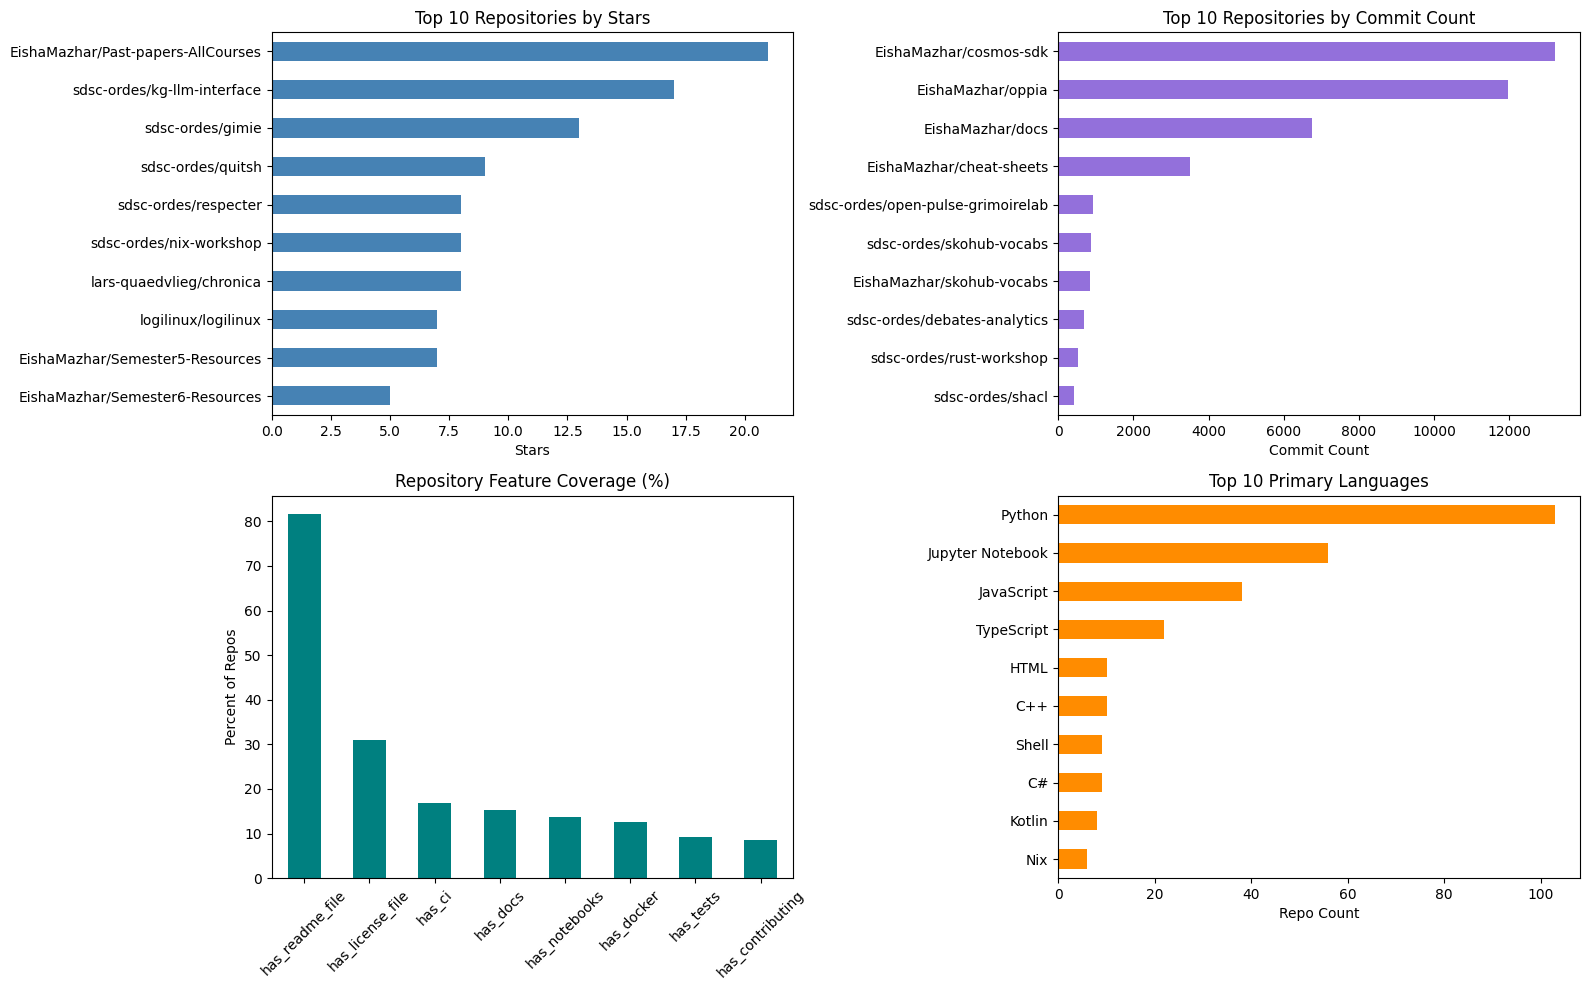

In [58]:
to_drop = ['is_private']

repo_metadata_df = repo_metadata_df.drop(columns=to_drop, errors="ignore")

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1) Top 10 repos by stars
top_starred = (
    repo_metadata_df[["name_with_owner", "stars"]]
    .dropna(subset=["name_with_owner"])
    .nlargest(10, "stars")
    .sort_values("stars")
    .set_index("name_with_owner")
)
top_starred.plot(kind="barh", ax=axes[0, 0], legend=False, color="steelblue")
axes[0, 0].set_title("Top 10 Repositories by Stars")
axes[0, 0].set_xlabel("Stars")
axes[0, 0].set_ylabel("")

# 2) Top 10 repos by commit count (easier to read than histogram)
if "commit_count_default_branch" in repo_metadata_df.columns:
    top_commits = (
        repo_metadata_df[["name_with_owner", "commit_count_default_branch"]]
        .dropna(subset=["name_with_owner"])
        .assign(commit_count_default_branch=lambda d: pd.to_numeric(d["commit_count_default_branch"], errors="coerce").fillna(0))
        .nlargest(10, "commit_count_default_branch")
        .sort_values("commit_count_default_branch")
        .set_index("name_with_owner")
    )

    top_commits.plot(
        kind="barh",
        ax=axes[0, 1],
        legend=False,
        color="mediumpurple"
    )
    axes[0, 1].set_title("Top 10 Repositories by Commit Count")
    axes[0, 1].set_xlabel("Commit Count")
    axes[0, 1].set_ylabel("")
else:
    axes[0, 1].text(0.5, 0.5, "commit_count_default_branch not found", ha="center", va="center")
    axes[0, 1].set_axis_off()

# 3) % of repos with key features
feature_cols = [c for c in repo_metadata_df.columns if c.startswith("has_")]
if feature_cols:
    (repo_metadata_df[feature_cols].mean() * 100).sort_values(ascending=False).plot(
        kind="bar", ax=axes[1, 0], color="teal"
    )
    axes[1, 0].set_title("Repository Feature Coverage (%)")
    axes[1, 0].set_xlabel("")
    axes[1, 0].set_ylabel("Percent of Repos")
    axes[1, 0].tick_params(axis="x", rotation=45)

# 4) Top 10 primary languages
top_languages = (
    repo_metadata_df["primary_language"]
    .replace("", pd.NA)
    .dropna()
    .value_counts()
    .head(10)
    .sort_values()
)
top_languages.plot(kind="barh", ax=axes[1, 1], color="darkorange")
axes[1, 1].set_title("Top 10 Primary Languages")
axes[1, 1].set_xlabel("Repo Count")
axes[1, 1].set_ylabel("")

plt.tight_layout()
plt.show()

In [59]:
print(f"Total repos: {repo_metadata_df.repo_url.nunique()}\
      \nRepos with linked metadata: {repo_metadata_df.shape[0]-repo_metadata_df.error.nunique(dropna=True)}\
      \nNumber of repos linked with Hackathon projects: {repo_metadata_df.project_foreign_key.nunique()}")

Total repos: 355      
Repos with linked metadata: 326      
Number of repos linked with Hackathon projects: 195


194

In [216]:
repo_metadata_df[linked_project_mask & ~valid_repo_metadata_mask]


/var/folders/b1/02zlb8yx3m5_j30bfvwsxdr40000gn/T/ipykernel_40489/3426793292.py:1: Pandas4Warning: 'and' operations between boolean dtype and string are deprecated and will raise in a future version. Explicitly cast the strings to a boolean dtype before operating instead.
  repo_metadata_df[(repo_metadata_df['project_foreign_key']!="") & (repo_metadata_df['error'].notnull() & repo_metadata_df['error']!="")]


,repo_url,commit_count_default_branch,contributors_count,contributors_top,created_at,default_branch,description,dirs_total_count,files_root_entries,files_total_count,...,readme_title,releases_count,repo,repo_name,stars,topics,updated_at,url,watchers,error
0,https://github.com/22cav/lauzhack2025,21,4,"[{'contributions': 14, 'html_url': 'https://gi...",2025-11-22 13:18:04+00:00,lauzhack2025,Control Blender in real-time with hand gestures,19,"[{'path': '.gitignore', 'size': 485, 'type': '...",76,...,Gesture Control System,0,lauzhack2025,3DX,4,"[blender-addon, gesture-recognition, landmarks]",2025-11-25 19:56:45+00:00,https://github.com/22cav/3DX,0,
1,https://github.com/4cademy/I.R.I.S._LauzHack_2024,41,4,"[{'contributions': 24, 'html_url': 'https://gi...",2024-11-30 13:21:59+00:00,main,Our project for the Vitol challenge at LauzHac...,1,"[{'path': '.DS_Store', 'size': 6148, 'type': '...",13,...,IRIS - Intelligent Recognition & Image Search,0,I.R.I.S._LauzHack_2024,IRIS,2,[],2024-12-15 22:55:06+00:00,https://github.com/4cademy/IRIS,1,
2,https://github.com/ALIANTE-IoT/ALIANTE,29,5,"[{'contributions': 13, 'html_url': 'https://gi...",2025-11-22 11:25:55+00:00,main,A distributed system for automated biodiversit...,24,"[{'path': '.gitignore', 'size': 2251, 'type': ...",73,...,ALIANTE,0,ALIANTE,ALIANTE,0,[],2025-11-25 13:45:32+00:00,https://github.com/ALIANTE-IoT/ALIANTE,0,
3,https://github.com/AaronDinesh/lauzhack-2025,109,4,"[{'contributions': 49, 'html_url': 'https://gi...",2025-11-22 10:46:30+00:00,main,,19,"[{'path': '.gitignore', 'size': 5201, 'type': ...",66,...,,0,lauzhack-2025,lauzhack-2025,2,[],2025-11-27 19:23:09+00:00,https://github.com/AaronDinesh/lauzhack-2025,0,
4,https://github.com/Akbermet-Toktobekova/Lauz_h...,9,2,"[{'contributions': 8, 'html_url': 'https://git...",2025-11-22 20:56:29+00:00,main,,17,"[{'path': '.gitignore', 'size': 953, 'type': '...",123,...,Fraud Detection & AML Risk Assessment System,0,Lauz_hack_2025,Lauz_hack_2025,1,[],2025-12-24 01:47:07+00:00,https://github.com/Akbermet-Toktobekova/Lauz_h...,0,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
350,https://github.com/walid-as/sbb-ghost-rider,4,2,"[{'contributions': 3, 'html_url': 'https://git...",2025-11-22 14:51:40+00:00,main,LauzHack challenge 2025:,34,"[{'path': '.gitignore', 'size': 225, 'type': '...",69,...,GhostRider - Anonymous Ticket System,0,sbb-ghost-rider,sbb-ghost-rider,0,[],2025-11-23 11:10:03+00:00,https://github.com/walid-as/sbb-ghost-rider,0,
351,https://github.com/wesleymth/LauzHack2023-Auto...,65,4,"[{'contributions': 30, 'html_url': 'https://gi...",2023-05-14 20:39:18+00:00,main,,1,"[{'path': '.gitignore', 'size': 3151, 'type': ...",23,...,speaker-notes,0,LauzHack2023-AutoNote,LauzHack2023-SpeakerNotes,1,[],2023-12-04 17:08:53+00:00,https://github.com/wesleymth/LauzHack2023-Spea...,1,
352,https://github.com/wesleymth/Lauzhack-2024-Cou...,0,0,NaN,NaT,,,0,NaN,0,...,,0,Lauzhack-2024-Counting-Stuff,,0,NaN,NaT,,0,"[{'type': 'NOT_FOUND', 'path': ['repository'],..."
353,https://github.com/youssefouru/LauzHack,0,0,NaN,NaT,,,0,NaN,0,...,,0,LauzHack,,0,NaN,NaT,,0,"[{'type': 'NOT_FOUND', 'path': ['repository'],..."


In [217]:
repo_metadata_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 355 entries, 0 to 354
Data columns (total 56 columns):
 #   Column                            Non-Null Count  Dtype              
---  ------                            --------------  -----              
 0   repo_url                          355 non-null    string             
 1   commit_count_default_branch       355 non-null    int64              
 2   contributors_count                355 non-null    int64              
 3   contributors_top                  327 non-null    object             
 4   created_at                        327 non-null    datetime64[us, UTC]
 5   default_branch                    355 non-null    string             
 6   description                       355 non-null    string             
 7   dirs_total_count                  355 non-null    int64              
 8   files_root_entries                327 non-null    object             
 9   files_total_count                 355 non-null    int64              
 10  f

In [218]:
repo_metadata_df.isna().sum().sort_values(ascending=False)

latest_release_date                 328
last_commit_date_default_branch      31
first_commit_date_default_branch     31
contributors_top                     28
created_at                           28
pushed_at                            28
updated_at                           28
topics                               28
files_root_entries                   28
languages_top                        28
primary_language                      0
pull_requests_closed                  0
project_foreign_key                   0
repo_url                              0
parent_url                            0
parent_repo                           0
pull_requests_open                    0
owner                                 0
pull_requests_merged                  0
readme_text                           0
pull_requests_total                   0
readme_length                         0
license_spdx                          0
readme_title                          0
releases_count                        0


In [62]:
len(set(repo_metadata_df.index.to_list()))

355

In [ ]:
make 